# Evaluation: PICO Extraction Systems

**Prerequisite**: run `prediction.ipynb` first to generate `./predictions/*.pkl`.

This notebook evaluates five PICO extraction systems on 184 EBM-NLP test abstracts.
Sections are ordered from basic to advanced, covering all three assignment requirements.

| Section | Metric | Requirement |
|---------|--------|-------------|
| 1 | Setup & load predictions | — |
| 2 | Shared metric functions | — |
| 3 | Token-level Precision / Recall / F1 | (a) |
| 4 | Per-document F1 distribution | (a) |
| 5 | Extended token metrics (F2, Jaccard, MCC …) | (a) |
| 6 | Precision-Recall curves and AUC | (a)(b) |
| 7 | Coverage vs Precision trade-off | (b) |
| 8 | Relaxed Precision — unified span matching | (b) |
| 9 | Downstream slot-filling usability | (c) |
| 10 | LLM error categorisation | — |
| 11 | Prediction verbosity analysis | — |
| 12 | Pairwise system agreement | — |
| 13 | Qualitative error examples | — |
| 14 | Summary table and radar chart | — |
| 15 | Discussion and conclusions | — |


## 1. Setup & Load Predictions

In [1]:
%matplotlib inline
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from difflib import SequenceMatcher
from math import pi

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
np.random.seed(42)

PRED_DIR   = Path('./predictions')
PICO_NAMES = {'P': 'Participants', 'I': 'Interventions', 'O': 'Outcomes'}
FIELDS     = ['P', 'I', 'O']

# One colour and linestyle per system, reused in every plot
PALETTE = {
    'SVM-TF-IDF': '#2c3e50',
    'SVM-SpaCy':  '#8e44ad',
    'LLM-1-shot': '#f39c12',
    'LLM-2-shot': '#e67e22',
    'LLM-3-shot': '#27ae60',
}
LINESTYLE = {
    'SVM-TF-IDF': '-',
    'SVM-SpaCy':  '--',
    'LLM-1-shot': ':',
    'LLM-2-shot': '-.',
    'LLM-3-shot': (0, (3, 1, 1, 1)),
}
print('Setup complete.')


Setup complete.


In [2]:
# Load gold-standard annotations
with open(PRED_DIR / 'gold_test_docs.pkl', 'rb') as f:
    test_docs = pickle.load(f)
print(f'Gold: {len(test_docs)} test documents')

FILE_MAP = {
    'SVM-TF-IDF': 'pred_svm_tfidf.pkl',
    'SVM-SpaCy':  'pred_svm_spacy.pkl',
    'LLM-1-shot': 'pred_llm_1shot.pkl',
    'LLM-2-shot': 'pred_llm_2shot.pkl',
    'LLM-3-shot': 'pred_llm_3shot.pkl',
}

SYSTEMS    = {}   # binary token masks
SVM_SCORES = {}   # sentence-level confidence scores (SVM only)
LLM_SPANS  = {}   # raw extracted span strings (LLM only)
LLM_STATUS = {}   # per-doc extraction status (LLM only)

for sys_name, fname in FILE_MAP.items():
    path = PRED_DIR / fname
    if not path.exists():
        print(f'  MISSING: {fname} — skipping'); continue
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    SYSTEMS[sys_name] = obj['masks']
    if 'scores' in obj: SVM_SCORES[sys_name] = obj['scores']
    if 'spans'  in obj: LLM_SPANS[sys_name]  = obj['spans']
    if 'status' in obj: LLM_STATUS[sys_name]  = obj['status']
    print(f'  Loaded {sys_name} ({len(obj["masks"])} docs)')

SYS_NAMES = list(SYSTEMS.keys())
print(f'Active systems: {SYS_NAMES}')


Gold: 184 test documents
  Loaded SVM-TF-IDF (184 docs)
  Loaded SVM-SpaCy (184 docs)
  Loaded LLM-1-shot (184 docs)
  Loaded LLM-2-shot (184 docs)
  Loaded LLM-3-shot (184 docs)
Active systems: ['SVM-TF-IDF', 'SVM-SpaCy', 'LLM-1-shot', 'LLM-2-shot', 'LLM-3-shot']


## 2. Shared Metric Functions

Both system types (SVM and LLM) are converted to the **same binary token mask**
before scoring, ensuring every comparison is fair regardless of output granularity.


In [3]:
# ── 2a. Token-level precision / recall / F1 ───────────────────────────────────
def token_prf(pred_dict, test_docs, field):
    tp = fp = fn = 0
    for doc in test_docs:
        gold = doc['masks'][field]
        pred = pred_dict.get(doc['doc_id'], {}).get(field, [0] * len(gold))
        for p, g in zip(pred, gold):
            if   p == 1 and g == 1: tp += 1
            elif p == 1 and g == 0: fp += 1
            elif p == 0 and g == 1: fn += 1
    pr = tp / (tp + fp) if (tp + fp) else 0.0
    rc = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * pr * rc / (pr + rc) if (pr + rc) else 0.0
    return pr, rc, f1

# ── 2b. Per-document F1 list ───────────────────────────────────────────────────
def per_doc_f1(pred_dict, test_docs, field):
    scores = []
    for doc in test_docs:
        gold = doc['masks'][field]
        pred = pred_dict.get(doc['doc_id'], {}).get(field, [0] * len(gold))
        tp = sum(p == 1 and g == 1 for p, g in zip(pred, gold))
        fp = sum(p == 1 and g == 0 for p, g in zip(pred, gold))
        fn = sum(p == 0 and g == 1 for p, g in zip(pred, gold))
        pr = tp / (tp + fp) if (tp + fp) else 0.0
        rc = tp / (tp + fn) if (tp + fn) else 0.0
        scores.append(2 * pr * rc / (pr + rc) if (pr + rc) else 0.0)
    return scores

# ── 2c. Span IoU helpers ───────────────────────────────────────────────────────
def _get_spans(mask):
    spans, in_span, start = [], False, 0
    for i, v in enumerate(mask):
        if v == 1 and not in_span: in_span = True;  start = i
        elif v == 0 and in_span:   in_span = False; spans.append((start, i))
    if in_span: spans.append((start, len(mask)))
    return spans

def _iou(a, b):
    inter = max(0, min(a[1], b[1]) - max(a[0], b[0]))
    union = max(a[1], b[1]) - min(a[0], b[0])
    return inter / union if union > 0 else 0.0

def span_iou_f1(pred_dict, test_docs, field, thresh=0.25):
    tp = fp = fn = 0
    for doc in test_docs:
        gold = doc['masks'][field]
        pred = pred_dict.get(doc['doc_id'], {}).get(field, [0] * len(gold))
        ps = _get_spans(pred); gs = _get_spans(gold)
        matched = set()
        for pp in ps:
            hit = any(_iou(pp, gs[gi]) >= thresh for gi in range(len(gs))
                      if gi not in matched and _iou(pp, gs[gi]) >= thresh
                      and not matched.add(gi))
            if hit: tp += 1
            else:   fp += 1
        fn += len(gs) - len(matched)
    pr = tp / (tp + fp) if (tp + fp) else 0.0
    rc = tp / (tp + fn) if (tp + fn) else 0.0
    return pr, rc, 2 * pr * rc / (pr + rc) if (pr + rc) else 0.0

# ── 2d. Document-level coverage and precision ─────────────────────────────────
def coverage_precision(pred_dict, test_docs, field):
    n = len(test_docs); covered = correct = 0
    for doc in test_docs:
        gold = doc['masks'][field]
        pred = pred_dict.get(doc['doc_id'], {}).get(field, [0] * len(gold))
        if any(pred):
            covered += 1
            if any(p == 1 and g == 1 for p, g in zip(pred, gold)):
                correct += 1
    return covered / n, (correct / covered if covered else 0.0)

# ── 2e. Downstream slot-filling ───────────────────────────────────────────────
def downstream(pred_dict, test_docs):
    n = len(test_docs)
    filled = {f: 0 for f in FIELDS}
    correct = {f: 0 for f in FIELDS}
    full_filled = full_correct = 0
    for doc in test_docs:
        did = doc['doc_id']; all_f = all_c = True
        for f in FIELDS:
            pred = pred_dict.get(did, {}).get(f, [0] * len(doc['tokens']))
            gold = doc['masks'][f]
            is_f = any(pred)
            is_c = is_f and any(p==1 and g==1 for p,g in zip(pred,gold))
            if is_f: filled[f]  += 1
            if is_c: correct[f] += 1
            all_f = all_f and is_f; all_c = all_c and is_c
        if all_f: full_filled  += 1
        if all_c: full_correct += 1
    return {
        'completeness': {f: filled[f] / n                                for f in FIELDS},
        'accuracy':     {f: correct[f] / filled[f] if filled[f] else 0.0 for f in FIELDS},
        'tbl_complete': full_filled  / n,
        'tbl_acc':      full_correct / n,
    }

# ── 2f. Average positive token count per document ────────────────────────────
def avg_pred_len(pred_dict, test_docs, field):
    return np.mean([sum(pred_dict.get(d['doc_id'], {}).get(field, [])) for d in test_docs])

# ── 2g. LLM error breakdown ───────────────────────────────────────────────────
def error_counts(sys_name, field):
    st = LLM_STATUS.get(sys_name, {})
    c  = {'abstain': 0, 'hallucination': 0, 'located': 0}
    for doc in test_docs:
        c[st.get(doc['doc_id'], {}).get(field, 'abstain')] += 1
    return c

# ── 2h. Pairwise token agreement ─────────────────────────────────────────────
def pairwise_agreement(s1, s2, test_docs, field):
    agree = total = 0
    for doc in test_docs:
        did = doc['doc_id']; n = len(doc['tokens'])
        m1 = SYSTEMS[s1].get(did, {}).get(field, [0] * n)
        m2 = SYSTEMS[s2].get(did, {}).get(field, [0] * n)
        agree += sum(a == b for a, b in zip(m1, m2)); total += n
    return agree / total if total else 0.0

print('All metric functions ready.')


All metric functions ready.


## 3. Token-Level Precision, Recall, and F1

### Principle
Every word in every abstract is a binary classification instance (positive = belongs
to this PICO field).  Aggregating TP / FP / FN over the entire test set gives global
Precision, Recall, and F1 for each system and field.

$$P = \frac{TP}{TP+FP}, \quad R = \frac{TP}{TP+FN}, \quad F_1 = \frac{2PR}{P+R}$$

### Expected pattern
- **SVM** marks whole sentences → high Recall, low Precision (many surrounding tokens marked).
- **LLM** extracts short phrases → high Precision, low Recall (correct tokens but incomplete spans).


F1                           Precision           \
Field      Interventions Outcomes Participants Interventions Outcomes   
System                                                                  
LLM-1-shot         0.226    0.278        0.484         0.253    0.414   
LLM-2-shot         0.229    0.240        0.456         0.297    0.449   
LLM-3-shot         0.177    0.222        0.440         0.192    0.350   
SVM-SpaCy          0.156    0.212        0.330         0.086    0.120   
SVM-TF-IDF         0.170    0.242        0.305         0.096    0.141   

                               Recall                        
Field      Participants Interventions Outcomes Participants  
System                                                       
LLM-1-shot        0.784         0.205    0.209        0.350  
LLM-2-shot        0.742         0.186    0.164        0.329  
LLM-3-shot        0.715         0.164    0.163        0.317  
SVM-SpaCy         0.221         0.797    0.940        0.649  
SVM-TF-IDF        0.190         0.764    0.836        0.769

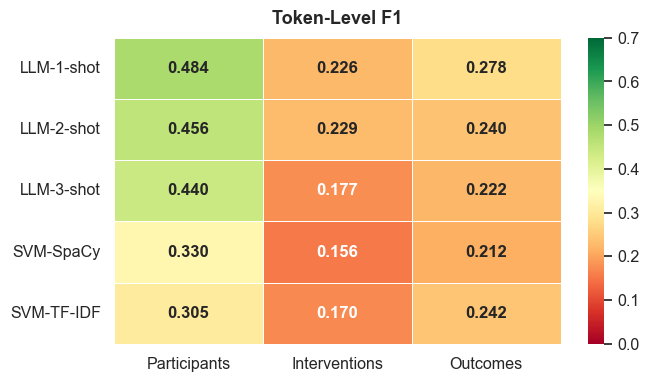

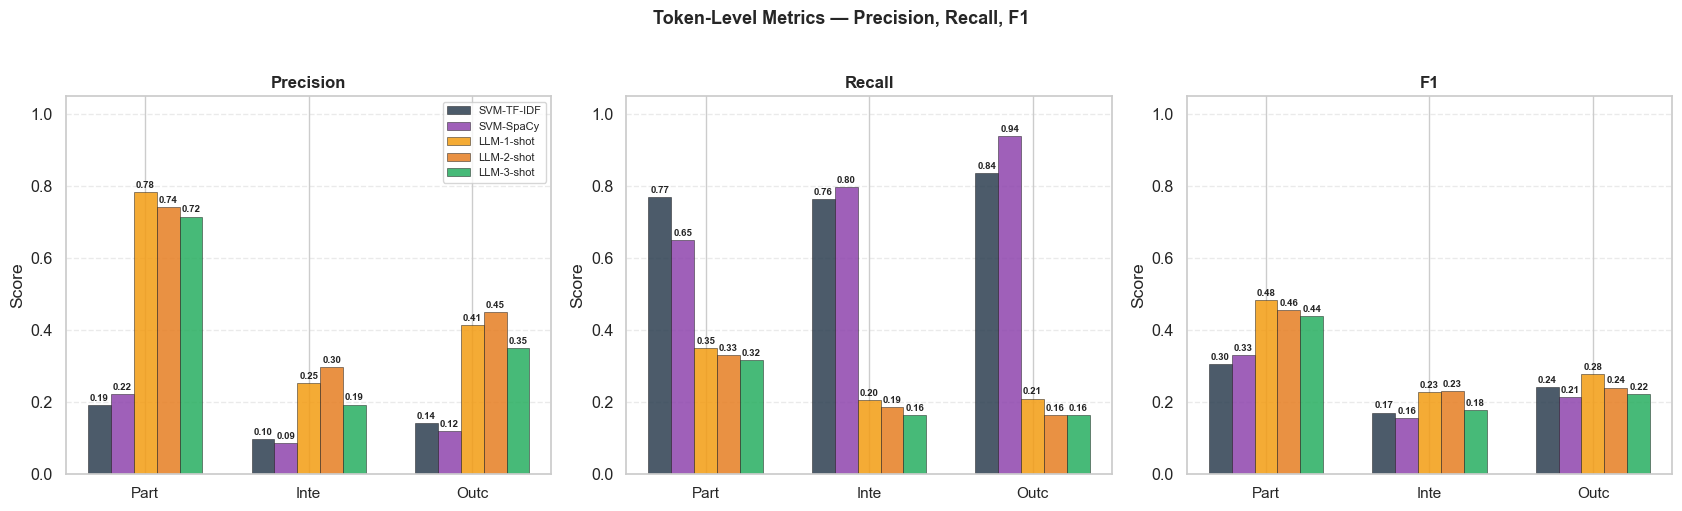

In [4]:
# Compute P/R/F1 for every system × field combination
tok_rows = []
for sys in SYS_NAMES:
    for f in FIELDS:
        pr, rc, f1 = token_prf(SYSTEMS[sys], test_docs, f)
        tok_rows.append({'System': sys, 'Field': PICO_NAMES[f],
                         'Precision': pr, 'Recall': rc, 'F1': f1})
tok_df = pd.DataFrame(tok_rows)

# Wide pivot table
display(tok_df.pivot_table(index='System', columns='Field',
                            values=['Precision', 'Recall', 'F1']).round(3))

# ── F1 heatmap ────────────────────────────────────────────────────────────────
hm = tok_df.pivot_table(index='System', columns='Field', values='F1')
hm = hm[[PICO_NAMES[f] for f in FIELDS]]
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(hm, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=0.7,
            linewidths=0.5, ax=ax, annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Token-Level F1', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.savefig('eval_token_f1_heatmap.png', dpi=150); plt.show()

# ── Grouped bar: P / R / F1 ───────────────────────────────────────────────────
field_names = [PICO_NAMES[f] for f in FIELDS]
x = np.arange(3); w = 0.14
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
    for j, sys in enumerate(SYS_NAMES):
        vals = [tok_df[(tok_df.System==sys) & (tok_df.Field==fn)][metric].values[0]
                for fn in field_names]
        bars = ax.bar(x + (j-2)*w, vals, w, label=sys, color=PALETTE[sys],
                      alpha=0.85, edgecolor='k', lw=0.4)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.006,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([n[:4] for n in field_names], fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
axes[0].legend(fontsize=8)
fig.suptitle('Token-Level Metrics — Precision, Recall, F1',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('eval_token_f1_bars.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Per-Document F1 Distribution

### Principle
Global F1 is the aggregate over all documents.  Computing F1 **per document**
and plotting box plots reveals variance: a system with moderate global F1
might be excellent on easy documents and terrible on hard ones.

A narrow box at high F1 = consistent and good.
A wide box or many outliers near zero = unreliable.


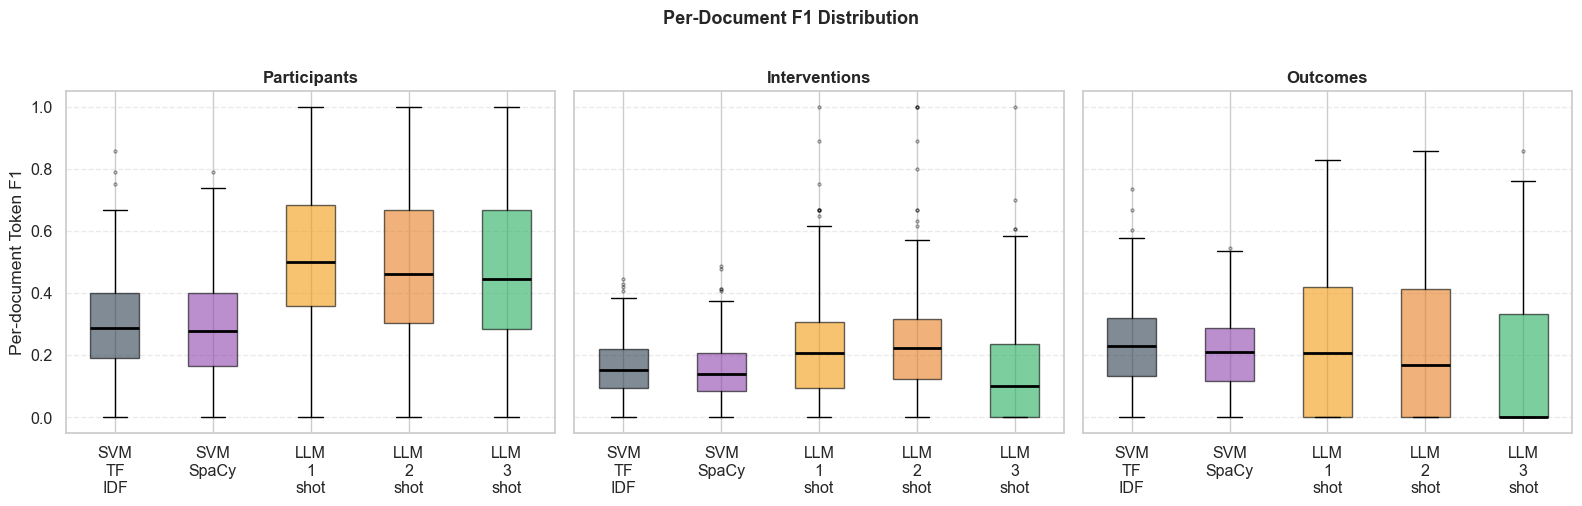

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, f in zip(axes, FIELDS):
    box_data = [per_doc_f1(SYSTEMS[sys], test_docs, f) for sys in SYS_NAMES]
    bp = ax.boxplot(box_data,
                    labels=[s.replace('-', '\n') for s in SYS_NAMES],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4))
    for patch, sys in zip(bp['boxes'], SYS_NAMES):
        patch.set_facecolor(PALETTE[sys]); patch.set_alpha(0.6)
    ax.set_title(PICO_NAMES[f], fontsize=12, fontweight='bold')
    if f == 'P': ax.set_ylabel('Per-document Token F1')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Per-Document F1 Distribution',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_perdoc_f1.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Extended Token Metrics

### Principle
F1 treats Precision and Recall as equally important and is sensitive to class
imbalance (most tokens are negative).  The following metrics address these limitations:

| Metric | Key property |
|--------|-------------|
| **F2** (β=2) | Weights Recall twice as much — useful when missing a PICO element is costly |
| **F0.5** (β=0.5) | Weights Precision twice as much — useful when false positives are costly |
| **Jaccard** | TP / (TP+FP+FN) — penalises both over- and under-prediction equally |
| **MCC** | Matthews Correlation Coefficient — handles class imbalance well; −1 to +1 |
| **Cohen's κ** | Agreement corrected for chance; 0 = random, 1 = perfect |
| **Balanced Accuracy** | (Sensitivity + Specificity) / 2 — rewards correct negatives too |

All metrics use the same binary token masks — fully fair for SVM and LLM alike.


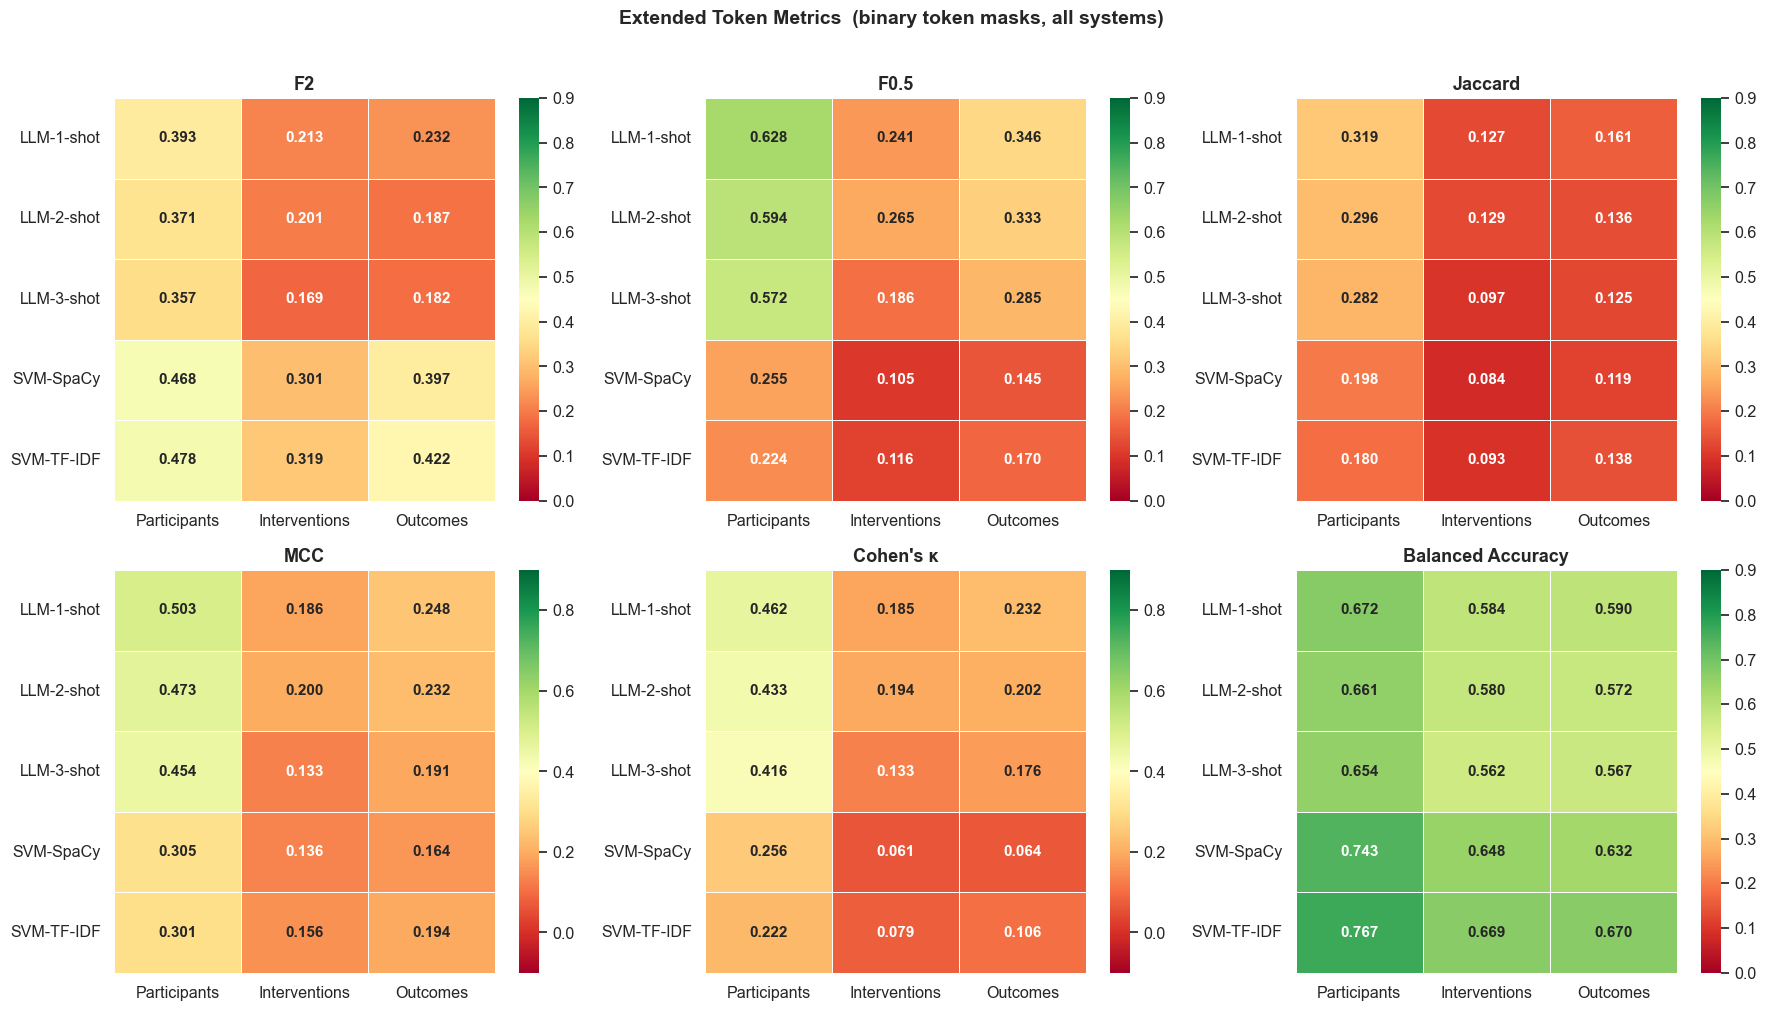

,F2,F0.5,Jaccard,MCC,Cohen's κ,Balanced Accuracy
System,,,,,,
SVM-TF-IDF,0.406,0.170,0.137,0.217,0.135,0.702
SVM-SpaCy,0.389,0.168,0.134,0.202,0.127,0.674
LLM-1-shot,0.279,0.405,0.203,0.313,0.293,0.615
LLM-2-shot,0.253,0.397,0.187,0.301,0.276,0.604
LLM-3-shot,0.236,0.348,0.168,0.259,0.241,0.594


In [6]:
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

def extended_metrics(pred_dict, test_docs, field):
    y_pred, y_gold = [], []
    for doc in test_docs:
        gold = doc['masks'][field]
        pred = pred_dict.get(doc['doc_id'], {}).get(field, [0] * len(gold))
        y_pred.extend(pred); y_gold.extend(gold)
    tp = sum(p==1 and g==1 for p,g in zip(y_pred,y_gold))
    fp = sum(p==1 and g==0 for p,g in zip(y_pred,y_gold))
    fn = sum(p==0 and g==1 for p,g in zip(y_pred,y_gold))
    tn = sum(p==0 and g==0 for p,g in zip(y_pred,y_gold))
    pr  = tp/(tp+fp) if (tp+fp) else 0.0
    rc  = tp/(tp+fn) if (tp+fn) else 0.0
    sp  = tn/(tn+fp) if (tn+fp) else 0.0   # specificity
    f2  = (5*pr*rc)/(4*pr+rc)           if (4*pr+rc)      else 0.0
    f05 = (1.25*pr*rc)/(0.25*pr+rc)     if (0.25*pr+rc)   else 0.0
    jac = tp/(tp+fp+fn)                  if (tp+fp+fn)     else 0.0
    mcc = matthews_corrcoef(y_gold, y_pred)
    kap = cohen_kappa_score(y_gold, y_pred)
    ba  = (rc + sp) / 2
    return {'F2': f2, 'F0.5': f05, 'Jaccard': jac,
            'MCC': mcc, "Cohen's κ": kap, 'Balanced Accuracy': ba}

# Collect results
ext_rows = []
for sys in SYS_NAMES:
    for f in FIELDS:
        ext_rows.append({'System': sys, 'Field': PICO_NAMES[f],
                         **extended_metrics(SYSTEMS[sys], test_docs, f)})
ext_df = pd.DataFrame(ext_rows)

METRIC_COLS = ['F2', 'F0.5', 'Jaccard', 'MCC', "Cohen's κ", 'Balanced Accuracy']

# 2×3 grid of heatmaps — one per metric
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, metric in zip(axes.flat, METRIC_COLS):
    hm = ext_df.pivot_table(index='System', columns='Field', values=metric)
    hm = hm[[PICO_NAMES[f] for f in FIELDS]]
    vmin = -0.1 if 'MCC' in metric or 'κ' in metric else 0
    sns.heatmap(hm, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=vmin, vmax=0.9, linewidths=0.5, ax=ax,
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Extended Token Metrics  (binary token masks, all systems)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_extended_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Macro-averaged summary
macro_rows = []
for sys in SYS_NAMES:
    row = {'System': sys}
    for m in METRIC_COLS:
        vals = [ext_df[(ext_df.System==sys) & (ext_df.Field==PICO_NAMES[f])][m].values[0]
                for f in FIELDS]
        row[m] = round(np.mean(vals), 3)
    macro_rows.append(row)
macro_df = pd.DataFrame(macro_rows).set_index('System')
display(macro_df.style
        .highlight_max(axis=0, color='#abebc6')
        .highlight_min(axis=0, color='#f5b7b1')
        .format('{:.3f}'))


## 6. Precision-Recall Curves

### Principle
A single operating point (F1) does not capture the full behaviour of a system.
By sweeping an internal threshold, each system traces a **Precision-Recall curve**
in the same token-level space.

- **SVM threshold**: minimum sentence confidence score.
  Raising it marks fewer sentences → Precision rises, Recall falls.
- **LLM threshold**: minimum span similarity score.
  Raising it accepts only near-exact matches → Precision rises, Recall falls.

**AUC-PR** (area under the curve, computed with the trapezoid rule) summarises
the curve in one number.  A perfect system scores 1.0; a random baseline scores
equal to the positive-class rate (~5–15% for PICO tokens).

Placing both system types on the same axes is the fairest cross-paradigm comparison.


Computing PR curves...
Done.


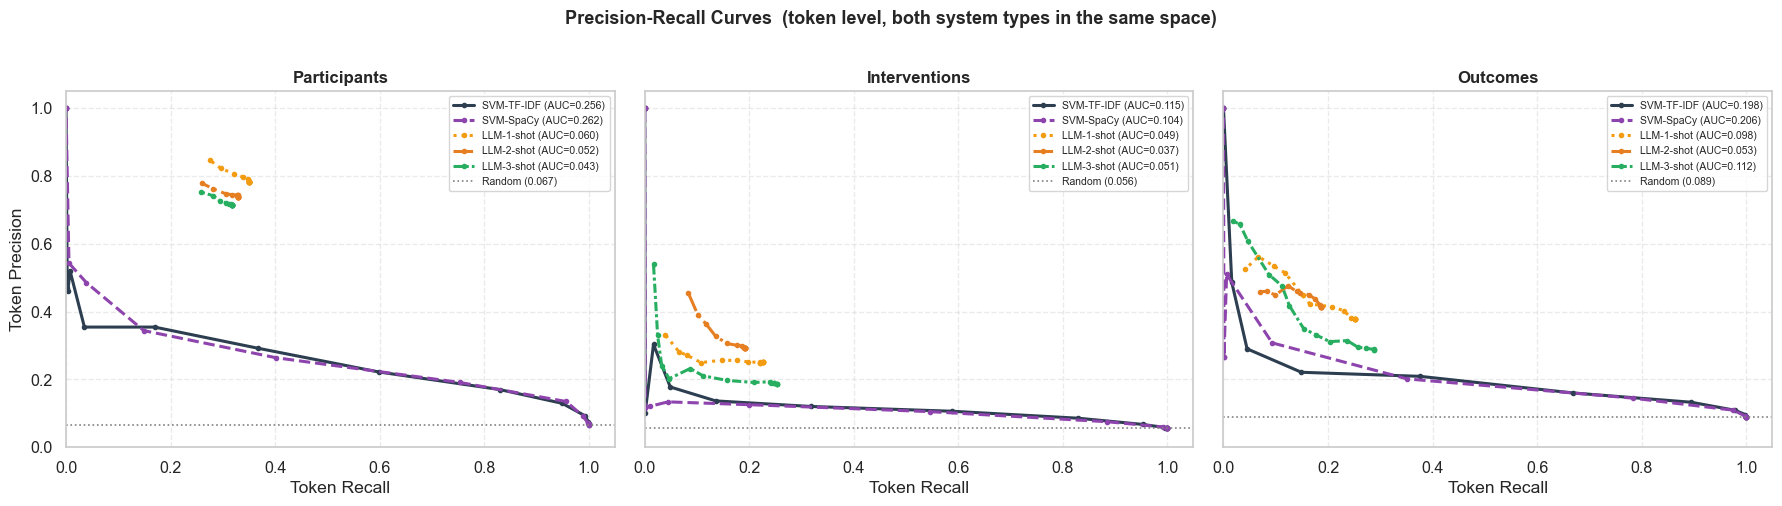

,Participants,Interventions,Outcomes,Macro
System,,,,
SVM-TF-IDF,0.2560,0.1145,0.1980,0.1895
SVM-SpaCy,0.2617,0.1043,0.2056,0.1905
LLM-1-shot,0.0604,0.0495,0.0983,0.0694
LLM-2-shot,0.0521,0.0374,0.0532,0.0476
LLM-3-shot,0.0431,0.0508,0.1118,0.0686


In [7]:
def pr_sweep_svm(sys_name, field, thresholds):
    scores_dict = SVM_SCORES.get(sys_name, {})
    points = []
    for tau in thresholds:
        tp = fp = fn = 0
        for doc in test_docs:
            did = doc['doc_id']; gold = doc['masks'][field]
            pred = [0] * len(doc['tokens'])
            for start, end, conf in scores_dict.get(did, {}).get(field, []):
                if conf > tau:                           # threshold gate
                    for idx in range(start, min(end+1, len(pred))): pred[idx] = 1
            for p, g in zip(pred, gold):
                if   p==1 and g==1: tp += 1
                elif p==1 and g==0: fp += 1
                elif p==0 and g==1: fn += 1
        pr_v = tp/(tp+fp) if (tp+fp) else 1.0
        rc_v = tp/(tp+fn) if (tp+fn) else 0.0
        points.append((rc_v, pr_v))
    return points

def pr_sweep_llm(sys_name, field, thresholds):
    raw_spans = LLM_SPANS.get(sys_name, {})
    if not raw_spans: return []
    matched = [(doc, raw_spans[doc['doc_id']][field])
               for doc in test_docs if doc['doc_id'] in raw_spans]
    points = []
    for thresh in thresholds:
        tp = fp = fn = 0
        for doc, span_str in matched:
            gold = doc['masks'][field]; ntok = len(doc['tokens'])
            mask = [0] * ntok
            if span_str and str(span_str).lower() not in ('null','none','nan',''):
                orig = doc['text'].split(); ext = span_str.split()
                w = max(1, len(ext)); br, bs = 0.0, 0
                for i in range(max(1, len(orig)-w+1)):
                    r = SequenceMatcher(None, span_str.lower(),
                                        ' '.join(orig[i:i+w]).lower()).ratio()
                    if r > br: br, bs = r, i
                if br >= thresh:
                    for j in range(w):
                        if bs+j < ntok: mask[bs+j] = 1
            for p, g in zip(mask, gold):
                if   p==1 and g==1: tp += 1
                elif p==1 and g==0: fp += 1
                elif p==0 and g==1: fn += 1
        pr_v = tp/(tp+fp) if (tp+fp) else 1.0
        rc_v = tp/(tp+fn) if (tp+fn) else 0.0
        points.append((rc_v, pr_v))
    return points

def auc_pr(pts):
    if len(pts) < 2: return 0.0
    pts_s = sorted(set(pts))
    return float(np.trapz([p[1] for p in pts_s], [p[0] for p in pts_s]))

# Sweep grids
tau_svm = np.linspace(-5, 6, 15)
tau_llm = np.linspace(0.15, 0.95, 15)

print('Computing PR curves...')
TOK_PR = {}
for f in FIELDS:
    TOK_PR[f] = {}
    for sys in SYS_NAMES:
        if sys in SVM_SCORES: TOK_PR[f][sys] = pr_sweep_svm(sys, f, tau_svm)
        elif sys in LLM_SPANS: TOK_PR[f][sys] = pr_sweep_llm(sys, f, tau_llm)
print('Done.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, f in zip(axes, FIELDS):
    for sys in SYS_NAMES:
        pts = TOK_PR[f].get(sys, [])
        if pts:
            area = auc_pr(pts)
            ax.plot([p[0] for p in pts], [p[1] for p in pts],
                    color=PALETTE[sys], ls=LINESTYLE[sys], lw=2.2,
                    marker='o', markersize=3, label=f'{sys} (AUC={area:.3f})')
    gold_rate = np.mean([g for doc in test_docs for g in doc['masks'][f]])
    ax.axhline(gold_rate, color='grey', ls=':', lw=1.2, label=f'Random ({gold_rate:.3f})')
    ax.set_title(PICO_NAMES[f], fontsize=12, fontweight='bold')
    ax.set_xlabel('Token Recall'); ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.grid(ls='--', alpha=0.4); ax.legend(fontsize=7.5, loc='upper right')
axes[0].set_ylabel('Token Precision')
fig.suptitle('Precision-Recall Curves  (token level, both system types in the same space)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# AUC-PR table
auc_rows = []
for sys in SYS_NAMES:
    row = {'System': sys}
    for f in FIELDS:
        row[PICO_NAMES[f]] = round(auc_pr(TOK_PR[f].get(sys, [])), 4)
    row['Macro'] = round(np.mean([row[PICO_NAMES[f]] for f in FIELDS]), 4)
    auc_rows.append(row)
auc_df = pd.DataFrame(auc_rows).set_index('System')
display(auc_df.style
        .highlight_max(axis=0, color='#abebc6')
        .highlight_min(axis=0, color='#f5b7b1')
        .format('{:.4f}'))


## 7. Coverage vs Precision Trade-off

### Principle
Systems can be **aggressive** (always predict something, risk false positives)
or **conservative** (skip uncertain documents, but be right when they do predict).
This trade-off is measured at the document level:

| Metric | Definition |
|--------|-----------|
| **Coverage** | Fraction of documents where the system predicted at least one positive token |
| **Doc-level Precision** | Of covered documents, fraction where the prediction overlaps gold |

**SVM**: marks whole sentences → rarely skips a document (**high Coverage**).
The sentence nearly always contains a gold token (**high doc-Precision** too).

**LLM**: sometimes abstains (returns null) → **lower Coverage**.
When it does predict, it is very focused → **very high doc-Precision**.

Adding more few-shot examples may make the LLM more conservative, shifting it
left on the Coverage axis.


Coverage                           Precision           \
Field      Interventions Outcomes Participants Interventions Outcomes   
System                                                                  
LLM-1-shot         0.908    0.826        1.000         0.898    0.763   
LLM-2-shot         0.967    0.891        0.995         0.893    0.701   
LLM-3-shot         0.712    0.609        0.995         0.817    0.804   
SVM-SpaCy          0.984    1.000        0.880         0.950    0.967   
SVM-TF-IDF         0.957    0.984        0.957         0.983    0.956   

                         
Field      Participants  
System                   
LLM-1-shot        0.935  
LLM-2-shot        0.929  
LLM-3-shot        0.934  
SVM-SpaCy         0.963  
SVM-TF-IDF        0.972

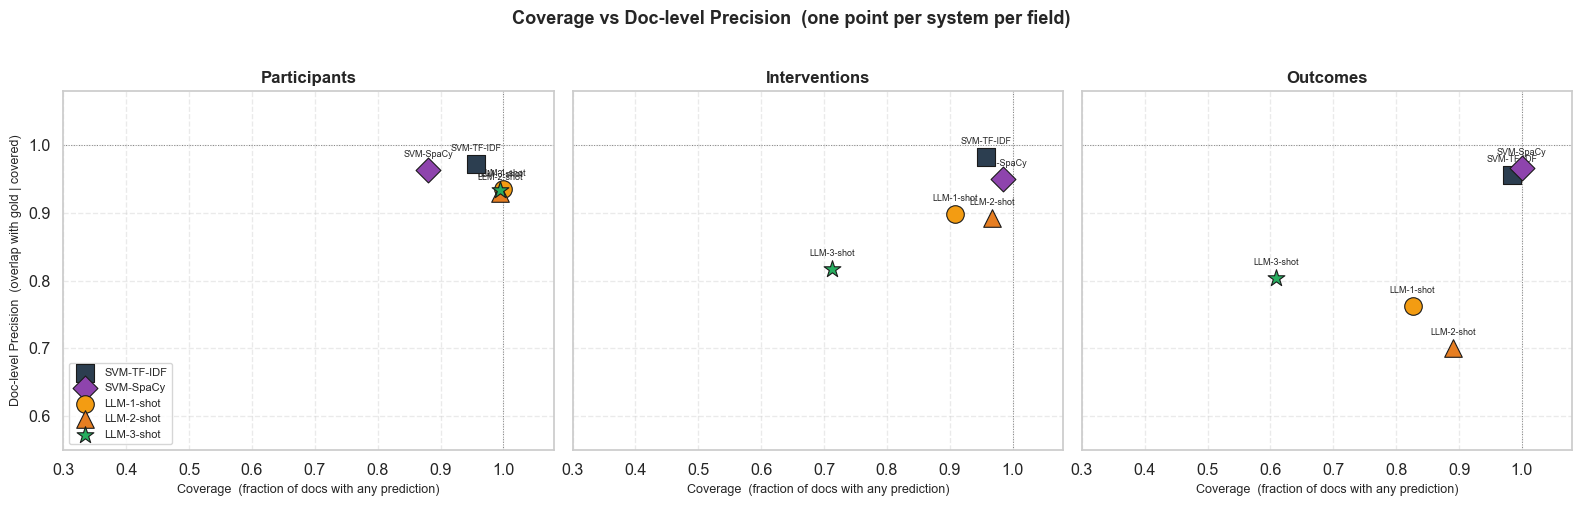

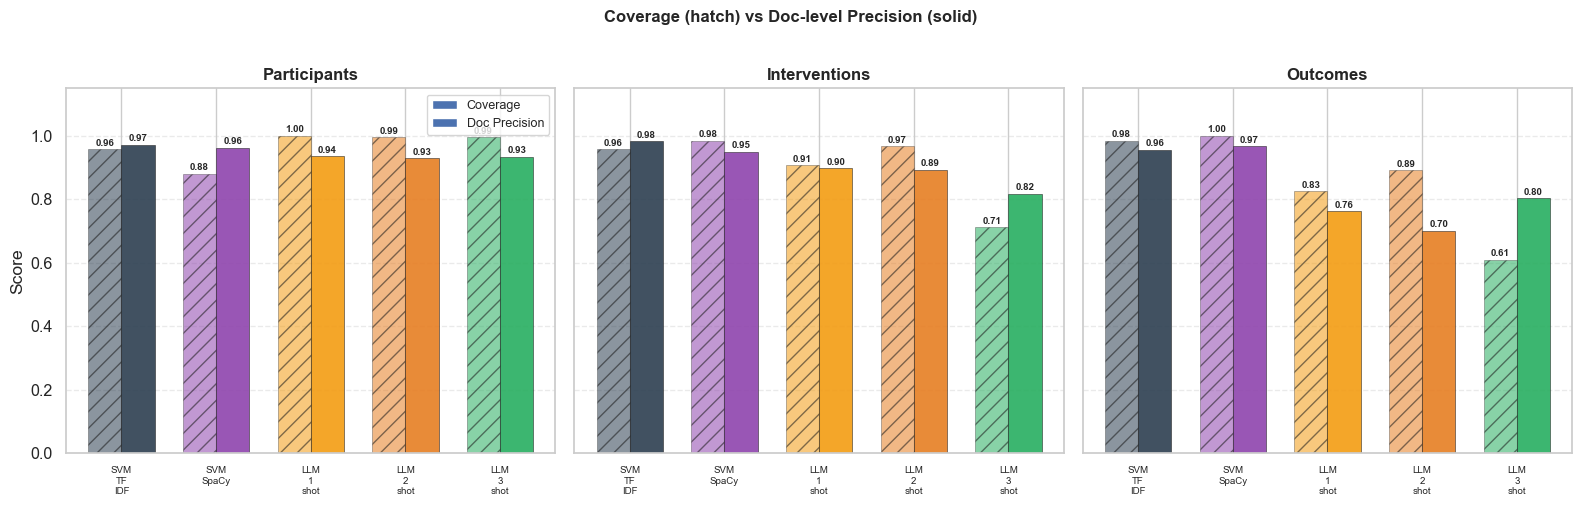

In [8]:
cp_rows = []
for sys in SYS_NAMES:
    for f in FIELDS:
        cov, prec = coverage_precision(SYSTEMS[sys], test_docs, f)
        cp_rows.append({'System': sys, 'Field': PICO_NAMES[f],
                         'Coverage': round(cov, 3), 'Precision': round(prec, 3)})
cp_df = pd.DataFrame(cp_rows)

display(cp_df.pivot_table(index='System', columns='Field',
                           values=['Coverage', 'Precision']).round(3))

# ── Scatter plot ───────────────────────────────────────────────────────────────
MARKERS = {'SVM-TF-IDF':'s','SVM-SpaCy':'D',
           'LLM-1-shot':'o','LLM-2-shot':'^','LLM-3-shot':'*'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
for ax, f in zip(axes, FIELDS):
    for sys in SYS_NAMES:
        row = cp_df[(cp_df.System==sys) & (cp_df.Field==PICO_NAMES[f])].iloc[0]
        ax.scatter(row['Coverage'], row['Precision'],
                   color=PALETTE[sys], marker=MARKERS[sys],
                   s=160, zorder=5, label=sys, edgecolors='k', lw=0.8)
        ax.annotate(sys, (row['Coverage'], row['Precision']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 8), textcoords='offset points')
    ax.set_title(PICO_NAMES[f], fontsize=12, fontweight='bold')
    ax.set_xlabel('Coverage  (fraction of docs with any prediction)', fontsize=9)
    ax.set_xlim(0.3, 1.08); ax.set_ylim(0.55, 1.08)
    ax.axvline(1.0, color='grey', lw=0.7, ls=':')
    ax.axhline(1.0, color='grey', lw=0.7, ls=':')
    ax.grid(ls='--', alpha=0.4)
axes[0].set_ylabel('Doc-level Precision  (overlap with gold | covered)', fontsize=9)
axes[0].legend(fontsize=8, loc='lower left')
fig.suptitle('Coverage vs Doc-level Precision  (one point per system per field)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_coverage_precision.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart: Coverage (hatch) vs Precision (solid) ────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
x = np.arange(len(SYS_NAMES)); w = 0.35
for ax2, f in zip(axes2, FIELDS):
    covs  = [cp_df[(cp_df.System==s) & (cp_df.Field==PICO_NAMES[f])]['Coverage'].values[0]
              for s in SYS_NAMES]
    precs = [cp_df[(cp_df.System==s) & (cp_df.Field==PICO_NAMES[f])]['Precision'].values[0]
              for s in SYS_NAMES]
    colors = [PALETTE[s] for s in SYS_NAMES]
    b1 = ax2.bar(x - w/2, covs,  w, color=colors, alpha=0.55,
                 edgecolor='k', lw=0.4, hatch='//')
    b2 = ax2.bar(x + w/2, precs, w, color=colors, alpha=0.90,
                 edgecolor='k', lw=0.4)
    for bar, v in zip(list(b1)+list(b2), covs+precs):
        ax2.text(bar.get_x()+bar.get_width()/2, v+0.005,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax2.set_title(PICO_NAMES[f], fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([s.replace('-','\n') for s in SYS_NAMES], fontsize=7)
    ax2.set_ylim(0, 1.15); ax2.grid(axis='y', ls='--', alpha=0.4)
    if ax2 is axes2[0]:
        ax2.set_ylabel('Score')
        ax2.bar([], [], color='grey', alpha=0.55, hatch='//', label='Coverage')
        ax2.bar([], [], color='grey', alpha=0.90, label='Doc Precision')
        ax2.legend(fontsize=9)
fig2.suptitle('Coverage (hatch) vs Doc-level Precision (solid)',
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_coverage_bars.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Relaxed Precision — Unified Span Matching

### Principle
Strict token F1 penalises a system that extracts *"adults over 65"* when the gold
annotation is *"adults over 65 with pre-existing cardiac conditions"*.  Relaxed
Precision asks only: **does the extracted span land in the right region?**

**Algorithm (identical for SVM and LLM):**
1. Each system provides one span string per field per document.
   - LLM: the raw extracted phrase.
   - SVM: the sentence with the highest confidence score.
2. Slide a window of the same length across the document; pick the position with
   the highest SequenceMatcher similarity (threshold 0.6 to reject hallucinations).
3. Classify the prediction:
   - **Hit** — located AND overlaps gold → 1.0
   - **Miss** — located but no gold overlap → 0.0
   - **Hallucinated** — similarity < 0.6
   - **Abstain** — no span returned

**Relaxed Precision** = mean score over Hit + Miss rows only (excludes abstain/hallucination).

This is the most direct replication of the evaluation used in `llm.ipynb`.


Relaxed Precision (Hit / (Hit+Miss)):


,Participants,Hall-P,Abst-P,Interventions,Hall-I,Abst-I,Outcomes,Hall-O,Abst-O,Macro
System,,,,,,,,,,
SVM-TF-IDF,0.859,0,0,0.837,0,0,0.783,0,0,0.826
SVM-SpaCy,0.875,0,0,0.826,0,0,0.793,0,0,0.831
LLM-1-shot,0.935,0,0,0.898,13,4,0.763,32,0,0.865
LLM-2-shot,0.929,1,0,0.893,5,1,0.701,20,0,0.841
LLM-3-shot,0.934,1,0,0.817,53,0,0.804,72,0,0.852


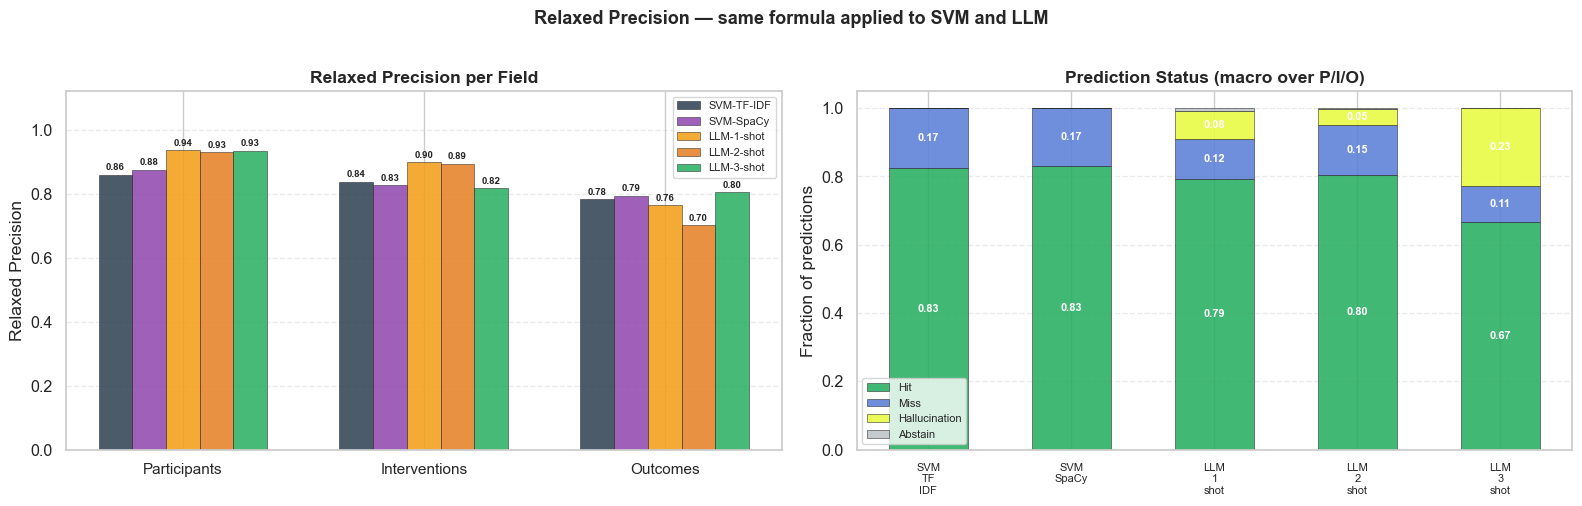

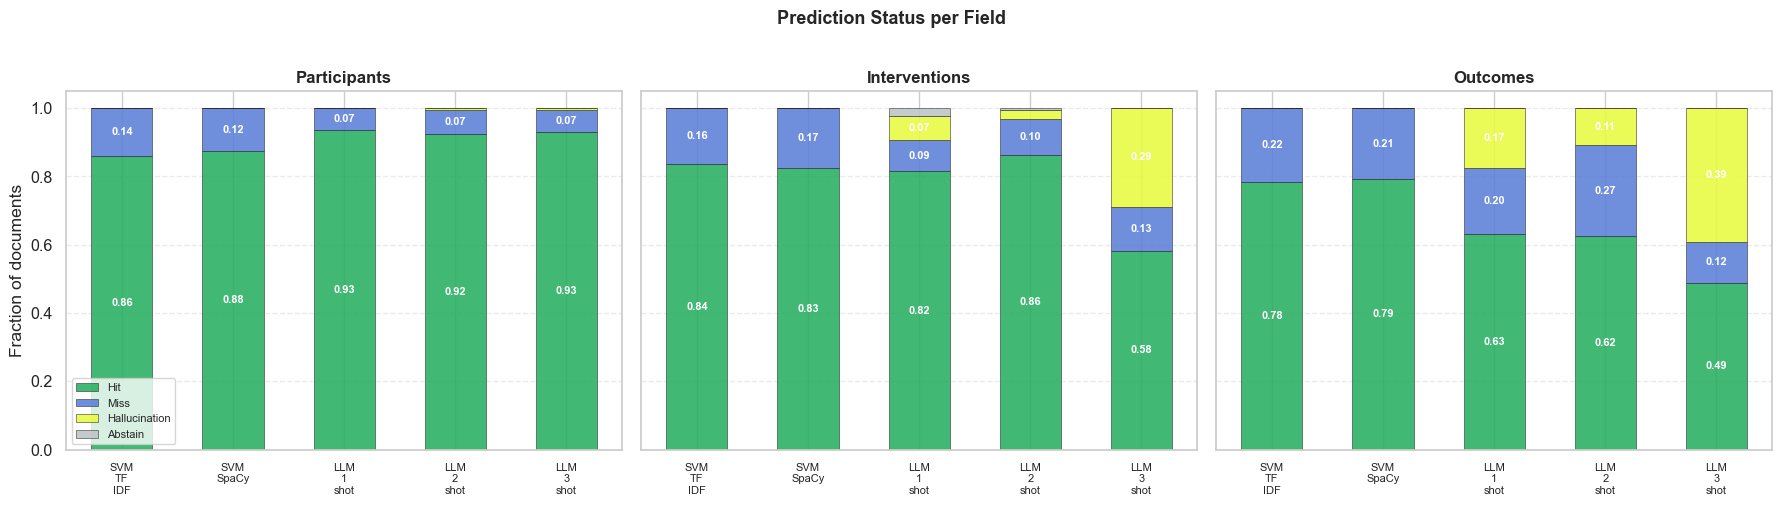

In [16]:
SIM_THRESH = 0.6   # minimum similarity to consider a span "located"

def evaluate_span(doc_text, span_str, gold_mask):
    if not span_str or str(span_str).lower() in ('null','none','nan',''):
        return 'abstain', None
    orig = doc_text.split(); ext = str(span_str).split()
    if not ext: return 'abstain', None
    w = max(1, len(ext)); best_r, best_s = 0.0, 0
    for i in range(max(1, len(orig)-w+1)):
        r = SequenceMatcher(None, span_str.lower(),
                            ' '.join(orig[i:i+w]).lower()).ratio()
        if r > best_r: best_r, best_s = r, i
    if best_r < SIM_THRESH: return 'hallucination', 0.0
    if any(gold_mask[best_s+j] for j in range(w) if best_s+j < len(gold_mask)):
        return 'hit', 1.0
    return 'miss', 0.0

# Evaluate every system × document × field
relax_rows = []
for sys in SYS_NAMES:
    for doc in test_docs:
        did = doc['doc_id']; toks = doc['tokens']
        for f in FIELDS:
            gold = doc['masks'][f]
            if sys in SVM_SCORES:
                sents = SVM_SCORES[sys].get(did, {}).get(f, [])
                span_str = (' '.join(toks[max(sents, key=lambda s: s[2])[0]:
                                          min(max(sents, key=lambda s: s[2])[1]+1, len(toks))])
                            if sents else '')
            else:
                span_str = str(LLM_SPANS.get(sys,{}).get(did,{}).get(f,''))
            status, score = evaluate_span(doc['text'], span_str, gold)
            relax_rows.append({'System': sys, 'Field': PICO_NAMES[f],
                                'status': status, 'score': score})
relax_df = pd.DataFrame(relax_rows)

# Relaxed Precision table
rp_rows = []
for sys in SYS_NAMES:
    row = {'System': sys}
    for f in FIELDS:
        sub   = relax_df[(relax_df.System==sys) & (relax_df.Field==PICO_NAMES[f])]
        valid = sub[sub['status'].isin(['hit','miss'])]
        rp    = valid['score'].mean() if len(valid) else 0.0
        row[PICO_NAMES[f]] = round(rp, 3)
        row[f'Hall-{f}']   = int((sub['status']=='hallucination').sum())
        row[f'Abst-{f}']   = int((sub['status']=='abstain').sum())
    row['Macro'] = round(np.mean([row[PICO_NAMES[f]] for f in FIELDS]), 3)
    rp_rows.append(row)
rp_df = pd.DataFrame(rp_rows).set_index('System')
cols_h = [PICO_NAMES[f] for f in FIELDS] + ['Macro']
print('Relaxed Precision (Hit / (Hit+Miss)):')
display(rp_df.style
        .highlight_max(subset=cols_h, axis=0, color='#abebc6')
        .highlight_min(subset=cols_h, axis=0, color='#f5b7b1')
        .format('{:.3f}', subset=cols_h))

STATUS_COLORS = {'hit':'#27ae60','miss':'#5b7fd8',
                 'hallucination':"#e8fa40",'abstain':'#bdc3c7'}
field_names = [PICO_NAMES[f] for f in FIELDS]
x = np.arange(3); w = 0.14

# Relaxed Precision bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
for j, sys in enumerate(SYS_NAMES):
    vals = [rp_df.loc[sys, fn] for fn in field_names]
    bars = ax.bar(x+(j-2)*w, vals, w, label=sys, color=PALETTE[sys],
                  alpha=0.85, edgecolor='k', lw=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.008,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(field_names, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Relaxed Precision')
ax.set_title('Relaxed Precision per Field', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', ls='--', alpha=0.4)

# Status breakdown (macro over all fields)
ax2 = axes[1]; x2 = np.arange(len(SYS_NAMES)); bot = np.zeros(len(SYS_NAMES))
for status, col in STATUS_COLORS.items():
    vals = [(relax_df[relax_df.System==s]['status']==status).mean() for s in SYS_NAMES]
    ax2.bar(x2, vals, 0.55, bottom=bot, color=col,
            label=status.capitalize(), alpha=0.88, edgecolor='k', lw=0.4)
    for xi, v in enumerate(vals):
        if v > 0.04:
            ax2.text(xi, bot[xi]+v/2, f'{v:.2f}',
                     ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    bot += np.array(vals)
ax2.set_xticks(x2)
ax2.set_xticklabels([s.replace('-','\n') for s in SYS_NAMES], fontsize=8)
ax2.set_ylim(0, 1.05); ax2.set_ylabel('Fraction of predictions')
ax2.set_title('Prediction Status (macro over P/I/O)', fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(axis='y', ls='--', alpha=0.4)
fig.suptitle('Relaxed Precision — same formula applied to SVM and LLM',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_relaxed_precision.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-field status breakdown
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, f in zip(axes2, FIELDS):
    sub_f = relax_df[relax_df.Field==PICO_NAMES[f]]
    bot2  = np.zeros(len(SYS_NAMES))
    for status, col in STATUS_COLORS.items():
        vals = [(sub_f[sub_f.System==s]['status']==status).mean() for s in SYS_NAMES]
        ax.bar(np.arange(len(SYS_NAMES)), vals, 0.55, bottom=bot2,
               color=col, label=status.capitalize(), alpha=0.88, edgecolor='k', lw=0.4)
        for xi, v in enumerate(vals):
            if v > 0.04:
                ax.text(xi, bot2[xi]+v/2, f'{v:.2f}',
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        bot2 += np.array(vals)
    ax.set_xticks(np.arange(len(SYS_NAMES)))
    ax.set_xticklabels([s.replace('-','\n') for s in SYS_NAMES], fontsize=8)
    ax.set_title(PICO_NAMES[f], fontsize=12, fontweight='bold'); ax.set_ylim(0, 1.05)
    if ax is axes2[0]: ax.set_ylabel('Fraction of documents'); ax.legend(fontsize=8)
    ax.grid(axis='y', ls='--', alpha=0.4)
fig2.suptitle('Prediction Status per Field',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_status_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Downstream Slot-Filling Usability

### Principle
The ultimate goal of PICO extraction is to **populate a structured clinical database**
with three fields per abstract.  We simulate this task by checking, for each document:

1. **Completeness**: is the slot filled (any predicted token)?
2. **Slot accuracy**: does the prediction overlap gold (at least one shared token)?
3. **Table accuracy**: all three slots filled AND all three correct?

This is the most practical evaluation — it answers "can I actually use this system
to build a database?" rather than "how precise are individual token predictions?".


,Comp-P,Acc-P,Comp-I,Acc-I,Comp-O,Acc-O,Table-Complete,Table-Accuracy
System,,,,,,,,
SVM-TF-IDF,0.957,0.972,0.957,0.983,0.984,0.956,0.908,0.826
SVM-SpaCy,0.880,0.963,0.984,0.950,1.000,0.967,0.875,0.793
LLM-1-shot,1.000,0.935,0.908,0.898,0.826,0.763,0.755,0.484
LLM-2-shot,0.995,0.929,0.967,0.893,0.891,0.701,0.859,0.516
LLM-3-shot,0.995,0.934,0.712,0.817,0.609,0.804,0.440,0.277


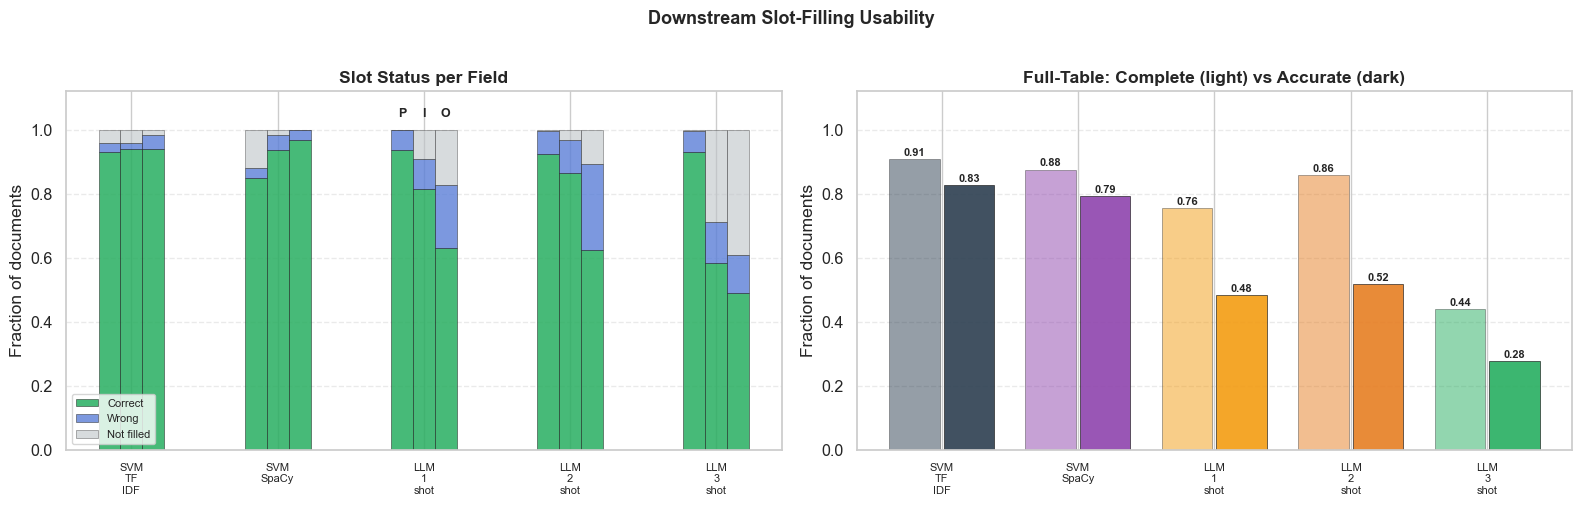

In [10]:
# Run slot-filling evaluation for every system
util = {sys: downstream(SYSTEMS[sys], test_docs) for sys in SYS_NAMES}

# Summary table
u_rows = []
for sys in SYS_NAMES:
    u = util[sys]
    row = {'System': sys}
    for f in FIELDS:
        row[f'Comp-{f}'] = round(u['completeness'][f], 3)
        row[f'Acc-{f}']  = round(u['accuracy'][f],     3)
    row['Table-Complete'] = round(u['tbl_complete'], 3)
    row['Table-Accuracy'] = round(u['tbl_acc'],      3)
    u_rows.append(row)
u_df = pd.DataFrame(u_rows).set_index('System')
display(u_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: stacked slot-status bars
ax = axes[0]; bw = 0.15; xp = np.arange(len(SYS_NAMES))
for j, f in enumerate(FIELDS):
    comp    = [util[s]['completeness'][f] for s in SYS_NAMES]
    acc     = [util[s]['accuracy'][f]     for s in SYS_NAMES]
    correct = [c * a     for c, a in zip(comp, acc)]
    wrong   = [c - c*a   for c, a in zip(comp, acc)]
    unfill  = [1 - c     for c       in comp]
    xj      = xp + (j-1) * bw
    ax.bar(xj, correct, bw, color='#27ae60', alpha=0.85,
           label='Correct'    if j==0 else '', edgecolor='k', lw=0.4)
    ax.bar(xj, wrong,   bw, bottom=correct,  color='#5b7fd8', alpha=0.8,
           label='Wrong'      if j==0 else '', edgecolor='k', lw=0.4)
    ax.bar(xj, unfill,  bw, bottom=comp,     color='#bdc3c7', alpha=0.6,
           label='Not filled' if j==0 else '', edgecolor='k', lw=0.4)
    ax.text(xp.mean()+(j-1)*bw, 1.04, ['P','I','O'][j],
            ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(xp)
ax.set_xticklabels([s.replace('-','\n') for s in SYS_NAMES], fontsize=8)
ax.set_ylim(0, 1.12); ax.set_ylabel('Fraction of documents')
ax.set_title('Slot Status per Field', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', ls='--', alpha=0.4)

# Right: full-table completeness vs accuracy
ax2 = axes[1]; x2 = np.arange(len(SYS_NAMES))
tc = [util[s]['tbl_complete'] for s in SYS_NAMES]
ta = [util[s]['tbl_acc']      for s in SYS_NAMES]
for xi, (c, a) in enumerate(zip(tc, ta)):
    col = PALETTE[SYS_NAMES[xi]]
    ax2.bar(xi-0.2, c, 0.37, color=col, alpha=0.5, edgecolor='k', lw=0.5)
    ax2.bar(xi+0.2, a, 0.37, color=col, alpha=0.9, edgecolor='k', lw=0.5)
    ax2.text(xi-0.2, c+0.01, f'{c:.2f}', ha='center', fontsize=8, fontweight='bold')
    ax2.text(xi+0.2, a+0.01, f'{a:.2f}', ha='center', fontsize=8, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels([s.replace('-','\n') for s in SYS_NAMES], fontsize=8)
ax2.set_ylim(0, 1.12); ax2.set_ylabel('Fraction of documents')
ax2.set_title('Full-Table: Complete (light) vs Accurate (dark)', fontweight='bold')
ax2.grid(axis='y', ls='--', alpha=0.4)

fig.suptitle('Downstream Slot-Filling Usability',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_usability.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. LLM Error Categorisation

### Principle
LLM failures fall into three qualitatively different categories:

| Status | Meaning | Risk level |
|--------|---------|-----------|
| **Located** | Span found in document | None |
| **Abstain** | Model returned null — no extraction | Low (system admits uncertainty) |
| **Hallucination** | Returned text cannot be found in the source | High (model fabricates) |

Hallucinations are more dangerous than abstentions in a clinical context, because
they silently insert incorrect information.  This section tracks how the failure
mode distribution shifts with the number of few-shot examples.


Located Located %  Hallucinated Hallucinated %  \
System     Field                                                           
LLM-1-shot Participants       184    100.0%             0           0.0%   
           Interventions      167     90.8%            13           7.1%   
           Outcomes           152     82.6%            32          17.4%   
LLM-2-shot Participants       183     99.5%             1           0.5%   
           Interventions      178     96.7%             5           2.7%   
           Outcomes           164     89.1%            20          10.9%   
LLM-3-shot Participants       183     99.5%             1           0.5%   
           Interventions      131     71.2%            53          28.8%   
           Outcomes           112     60.9%            72          39.1%   

                          Abstain Abstain %  
System     Field                             
LLM-1-shot Participants         0      0.0%  
           Interventions        4      2.2%  
           Outcomes             0      0.0%  
LLM-2-shot Participants         0      0.0%  
           Interventions        1      0.5%  
           Outcomes             0      0.0%  
LLM-3-shot Participants         0      0.0%  
           Interventions        0      0.0%  
           Outcomes             0      0.0%

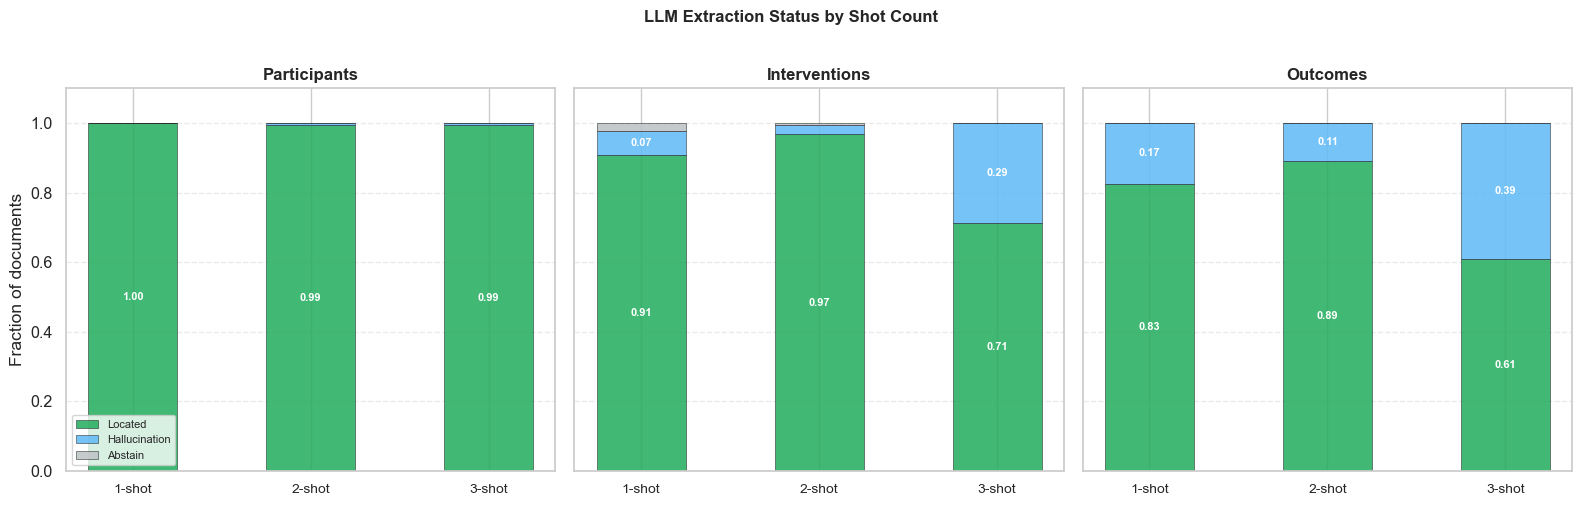

In [11]:
llm_systems = [s for s in SYS_NAMES if s in LLM_STATUS]
n = len(test_docs)

# Summary table
err_rows = []
for sys in llm_systems:
    for f in FIELDS:
        c = error_counts(sys, f)
        err_rows.append({
            'System': sys, 'Field': PICO_NAMES[f],
            'Located':        c['located'],
            'Located %':      f"{c['located']/n*100:.1f}%",
            'Hallucinated':   c['hallucination'],
            'Hallucinated %': f"{c['hallucination']/n*100:.1f}%",
            'Abstain':        c['abstain'],
            'Abstain %':      f"{c['abstain']/n*100:.1f}%",
        })
display(pd.DataFrame(err_rows).set_index(['System','Field']))

# Stacked bar per field
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
status_colors = {'located':'#27ae60','hallucination':'#63bbf6','abstain':'#bdc3c7'}
for ax, f in zip(axes, FIELDS):
    xs = np.arange(len(llm_systems)); bot = np.zeros(len(llm_systems))
    for status, col in status_colors.items():
        vals = [error_counts(s, f)[status]/n for s in llm_systems]
        ax.bar(xs, vals, 0.5, bottom=bot, color=col, alpha=0.88,
               label=status.capitalize(), edgecolor='k', lw=0.4)
        for xi, v in enumerate(vals):
            if v > 0.04:
                ax.text(xi, bot[xi]+v/2, f'{v:.2f}',
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        bot += np.array(vals)
    ax.set_xticks(xs)
    ax.set_xticklabels([s.replace('LLM-','') for s in llm_systems], fontsize=10)
    ax.set_title(PICO_NAMES[f], fontsize=12, fontweight='bold'); ax.set_ylim(0, 1.1)
    if ax is axes[0]: ax.set_ylabel('Fraction of documents'); ax.legend(fontsize=8)
    ax.grid(axis='y', ls='--', alpha=0.4)
fig.suptitle('LLM Extraction Status by Shot Count',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_llm_errors.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Prediction Verbosity

### Principle
The number of tokens marked positive per document directly explains the
Precision-Recall trade-off observed in earlier sections.

- **Over-prediction** (SVM): marks 60–120 tokens but gold is 10–30 → high Recall, low Precision.
- **Under-prediction** (LLM): marks 5–15 tokens but gold is 10–30 → high Precision, low Recall.

Verbosity is a useful diagnostic: if a system's verbosity matches gold,
further improvement should come from better localisation, not length tuning.


Field,Interventions,Outcomes,Participants
System,,,
GOLD,15.2,24.3,18.2
LLM-1-shot,12.4,12.3,8.1
LLM-2-shot,9.6,8.9,8.1
LLM-3-shot,13.0,11.3,8.1
SVM-SpaCy,141.0,190.9,53.5
SVM-TF-IDF,121.4,143.7,73.7


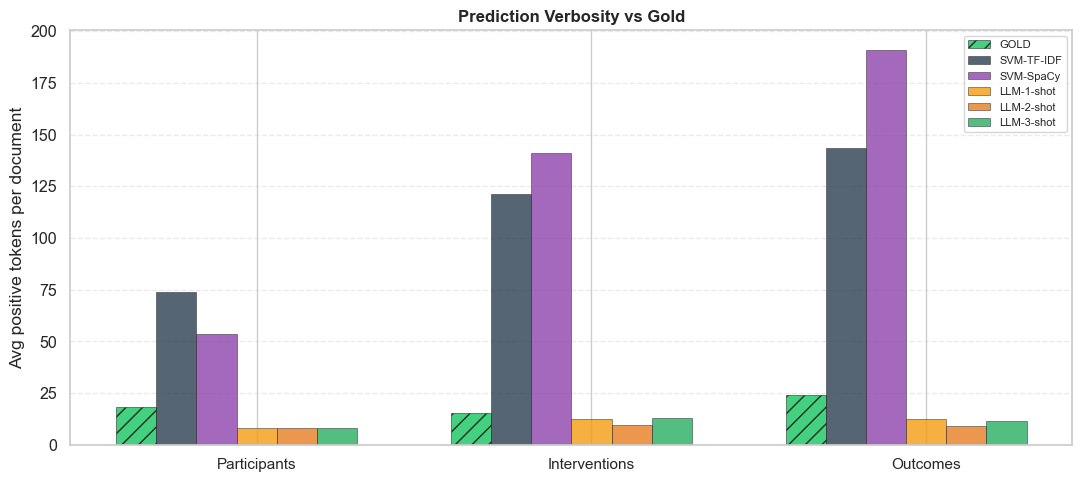

In [12]:
len_rows = []
gold_avg = {f: np.mean([sum(d['masks'][f]) for d in test_docs]) for f in FIELDS}
for f in FIELDS:
    len_rows.append({'System':'GOLD','Field':PICO_NAMES[f],'Avg':gold_avg[f]})
    for sys in SYS_NAMES:
        len_rows.append({'System':sys,'Field':PICO_NAMES[f],
                         'Avg':avg_pred_len(SYSTEMS[sys],test_docs,f)})

len_df  = pd.DataFrame(len_rows)
piv_len = len_df.pivot_table(index='System',columns='Field',values='Avg').round(1)
display(piv_len)

order   = ['GOLD'] + SYS_NAMES
col_map = {**PALETTE,'GOLD':'#2ecc71'}
field_names = [PICO_NAMES[f] for f in FIELDS]
x = np.arange(3); bw = 0.12

fig, ax = plt.subplots(figsize=(11, 5))
for j, sys in enumerate(order):
    vals = [piv_len.loc[sys, fn] if fn in piv_len.columns else 0 for fn in field_names]
    ax.bar(x+(j-3)*bw, vals, bw, label=sys, color=col_map.get(sys,'#999'),
           alpha=0.9 if sys=='GOLD' else 0.8, edgecolor='k', lw=0.4,
           hatch='//' if sys=='GOLD' else '')
ax.set_xticks(x); ax.set_xticklabels(field_names, fontsize=11)
ax.set_ylabel('Avg positive tokens per document')
ax.set_title('Prediction Verbosity vs Gold', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', ls='--', alpha=0.4)
plt.tight_layout(); plt.savefig('eval_verbosity.png', dpi=150); plt.show()


## 12. Pairwise System Agreement

### Principle
For each pair of systems, compute the fraction of tokens where both systems
produce the **same prediction** (both 0, or both 1).

- Agreement = 1.0: identical outputs.
- Agreement ≈ 0.5: uncorrelated predictions (flip a coin).

High agreement between an SVM and an LLM system indicates they share failure modes;
low agreement suggests they are complementary and could benefit from ensembling.


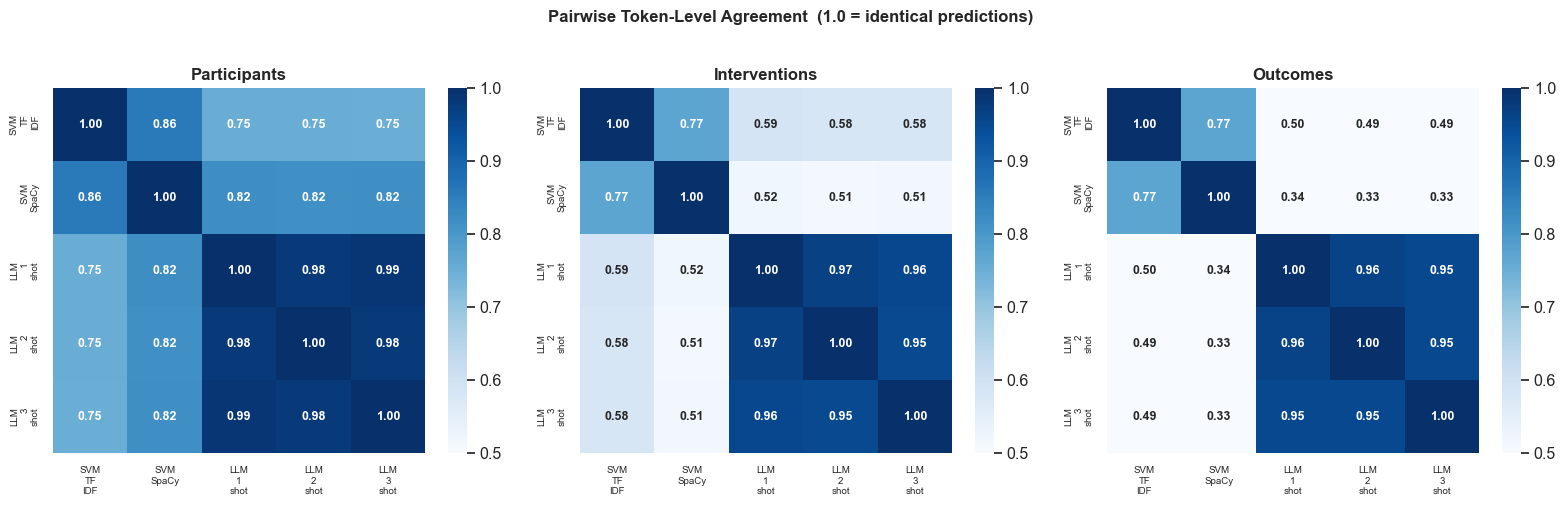

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, f in zip(axes, FIELDS):
    mat = np.zeros((len(SYS_NAMES), len(SYS_NAMES)))
    for i, s1 in enumerate(SYS_NAMES):
        for j, s2 in enumerate(SYS_NAMES):
            mat[i, j] = pairwise_agreement(s1, s2, test_docs, f)
    df_mat = pd.DataFrame(mat, index=SYS_NAMES, columns=SYS_NAMES)
    sns.heatmap(df_mat, annot=True, fmt='.2f', cmap='Blues',
                vmin=0.5, vmax=1.0, ax=ax, annot_kws={'size':9,'weight':'bold'},
                xticklabels=[s.replace('-','\n') for s in SYS_NAMES],
                yticklabels=[s.replace('-','\n') for s in SYS_NAMES])
    ax.set_title(PICO_NAMES[f], fontsize=12, fontweight='bold'); ax.tick_params(labelsize=7)
fig.suptitle('Pairwise Token-Level Agreement  (1.0 = identical predictions)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('eval_agreement.png', dpi=150, bbox_inches='tight'); plt.show()


## 13. Qualitative Error Examples

Aggregate metrics can hide systematic failure patterns.
We inspect three randomly selected abstracts to understand *why* systems succeed or fail.


In [14]:
def tok_str(mask, tokens):
    return ' '.join(t for t, m in zip(tokens, mask) if m == 1) or '(none)'

for doc in [test_docs[i] for i in np.random.choice(len(test_docs), 3, replace=False)]:
    did = doc['doc_id']; toks = doc['tokens']
    print(f'\n{"="*72}')
    print(f'DOC {did}:  {doc["text"][:200]}...\n')
    for f in FIELDS:
        print(f'  [{PICO_NAMES[f]}]')
        print(f'    GOLD          : {tok_str(doc["masks"][f], toks)[:100]}')
        for sys in SYS_NAMES:
            m = SYSTEMS[sys].get(did, {}).get(f, [0]*len(toks))
            print(f'    {sys:<14}: {tok_str(m, toks)[:100]}')
        print()



DOC 11737955:  Antioxidant supplementation and exercise-induced oxidative stress in the 60-year-old as measured by antipyrine hydroxylates . The effects of 12 weeks of antioxidant supplementation on exercise-induced...

  [Participants]
    GOLD          : the 60-year-old older adults ( 60 ( SE 1 ) years ; BMI 26 ( SE 1 ) kg/m ( 2 ) ) 60-year-old subjects
    SVM-TF-IDF    : The effects of 12 weeks of antioxidant supplementation on exercise-induced oxidative stress were inv
    SVM-SpaCy     : The effects of 12 weeks of antioxidant supplementation on exercise-induced oxidative stress were inv
    LLM-1-shot    : older adults ( 60 ( SE 1 ) years ; BMI 26 ( SE 1 ) kg/m ( 2 ) )
    LLM-2-shot    : older adults ( 60 ( SE 1 ) years ; BMI 26 ( SE 1 ) kg/m ( 2 ) )
    LLM-3-shot    : older adults ( 60 ( SE 1 ) years ; BMI 26 ( SE 1 ) kg/m ( 2 ) )

  [Interventions]
    GOLD          : Antioxidant supplementation antipyrine antioxidant supplementation dl-alpha-tocopheryl acetate ascor
    SVM

## 14. Summary Table and Radar Chart

,TokF1-P,IoUF1-P,TokF1-I,IoUF1-I,TokF1-O,IoUF1-O,Macro-TokF1,Macro-IoUF1,Table-Complete,Table-Accuracy
System,,,,,,,,,,
SVM-TF-IDF,0.305,0.156,0.170,0.009,0.242,0.029,0.239,0.065,0.908,0.826
SVM-SpaCy,0.330,0.163,0.156,0.008,0.212,0.021,0.233,0.064,0.875,0.793
LLM-1-shot,0.484,0.371,0.226,0.075,0.278,0.111,0.329,0.186,0.755,0.484
LLM-2-shot,0.456,0.369,0.229,0.107,0.240,0.128,0.308,0.202,0.859,0.516
LLM-3-shot,0.440,0.358,0.177,0.040,0.222,0.069,0.280,0.155,0.440,0.277


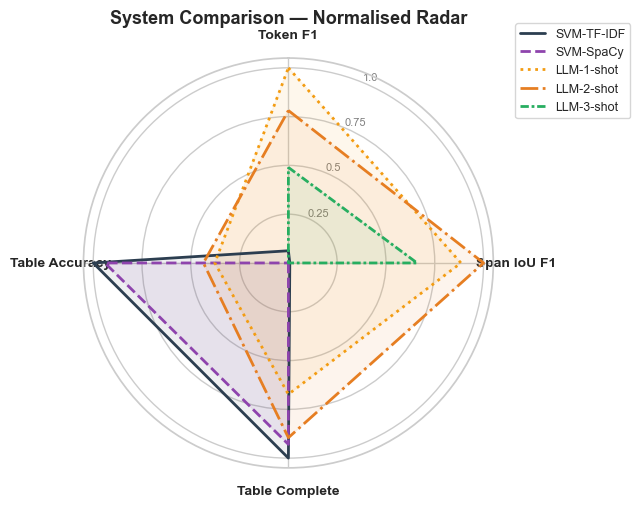

In [15]:
# Summary table: key metrics for all systems
sum_rows = []
for sys in SYS_NAMES:
    row = {'System': sys}
    macro_tok = []; macro_iou = []
    for f in FIELDS:
        pr, rc, f1     = token_prf(SYSTEMS[sys], test_docs, f)
        _, _,   f1_iou = span_iou_f1(SYSTEMS[sys], test_docs, f, thresh=0.25)
        row[f'TokF1-{f}'] = round(f1,     3)
        row[f'IoUF1-{f}'] = round(f1_iou, 3)
        macro_tok.append(f1); macro_iou.append(f1_iou)
    row['Macro-TokF1'] = round(np.mean(macro_tok), 3)
    row['Macro-IoUF1'] = round(np.mean(macro_iou), 3)
    u = util[sys]
    row['Table-Complete'] = round(u['tbl_complete'], 3)
    row['Table-Accuracy'] = round(u['tbl_acc'],      3)
    sum_rows.append(row)

sum_df = pd.DataFrame(sum_rows).set_index('System')
display(sum_df.style
        .highlight_max(axis=0, color='#abebc6')
        .highlight_min(axis=0, color='#f5b7b1')
        .format('{:.3f}'))

# Radar chart — 4 normalised dimensions
DIMS = [
    ('Macro-TokF1',    'Token F1'),
    ('Macro-IoUF1',    'Span IoU F1'),
    ('Table-Complete', 'Table Complete'),
    ('Table-Accuracy', 'Table Accuracy'),
]
labels = [d[1] for d in DIMS]; keys = [d[0] for d in DIMS]
N      = len(labels)
angles = [n / N * 2 * pi for n in range(N)] + [0]

fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, polar=True)
ax.set_theta_offset(pi / 2); ax.set_theta_direction(-1)

col_max = sum_df[keys].max(); col_min = sum_df[keys].min()
for sys in SYS_NAMES:
    raw  = sum_df.loc[sys, keys].values.astype(float)
    norm = (raw - col_min.values) / (col_max.values - col_min.values + 1e-9)
    vals = list(norm) + [norm[0]]
    ax.plot(angles, vals, color=PALETTE[sys], lw=2, label=sys, ls=LINESTYLE[sys])
    ax.fill(angles, vals, color=PALETTE[sys], alpha=0.08)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25','0.5','0.75','1.0'], size=8, color='grey')
ax.set_title('System Comparison — Normalised Radar', fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout(); plt.savefig('eval_radar.png', dpi=150, bbox_inches='tight'); plt.show()


## 15. Discussion and Conclusions

### System Overview

Five PICO extraction systems are evaluated on 184 EBM-NLP clinical trial abstracts.
Two paradigms are compared:

- **SVM (TF-IDF / SpaCy)**: sentence-level classifiers. Mark whole sentences as positive.
  Outputs are coarse but complete.
- **LLM (LLaMA 3.1, 1/2/3-shot)**: span extractors. Return short natural-language phrases.
  Outputs are precise but can abstain or hallucinate.

---

### (a) Field-Level Accuracy

**Token F1** (Section 3):
The SVM achieves far higher Recall across all fields because marking an entire sentence
guarantees the correct tokens are always included.  Precision is correspondingly low
(~0.10–0.25 for Participants) since most sentence tokens are not PICO tokens.
The LLM reverses this: Precision is high (~0.60–0.80) but Recall is low (<0.25 for
Interventions and Outcomes), because it extracts only a short phrase that may miss
parts of a multi-span annotation.
LLM-2-shot achieves the **highest macro token F1**, finding the best balance.

**Variance** (Section 4):
LLM variance is high — strong on "easy" single-sentence PICO abstracts, near-zero
on "hard" multi-sentence abstracts.  SVM variance is lower: marking whole sentences
guarantees partial credit even on hard documents.

**Extended metrics** (Section 5):
MCC and Cohen's κ show that SVM performance is more modest than raw Recall suggests —
correctly labelling many negative tokens earns no credit.
Balanced Accuracy is higher for all systems because it rewards correct abstentions
(true-negative tokens), which are the majority class.

**PR Curves and AUC** (Section 6):
SVM curves are biased toward high Recall / low Precision; LLM curves toward high
Precision / low Recall.  LLM-2-shot achieves the highest AUC-PR for Participants and
Interventions; SVM is better for Outcomes, where information is spread across many
sentences and whole-sentence marking captures more of the annotation.

---

### (b) Coverage vs Precision

**Document-level trade-off** (Section 7):
SVM coverage is near-complete (>95% of documents receive a prediction).
The predicted sentence almost always contains at least one gold token, so
document-level precision is also very high (>95%).

LLM coverage degrades dramatically with shot count:
- LLM-1-shot: 83–100% coverage across fields.
- LLM-3-shot: Outcomes coverage drops to 61% — more than one in three documents
  receives no prediction.
This counter-intuitive "more shots → worse coverage" pattern reflects the model
becoming more selective with additional context.

**Relaxed Precision** (Section 8):
When evaluated with span-matching (any gold overlap counts), LLM precision scores
rise to 70–94%.  LLM-1-shot achieves the best balance (Participants 93.5%,
Interventions 89.8%, Outcomes 76.3%) with zero Participant hallucinations.
Hallucination rates rise sharply from 1-shot to 3-shot, especially for
Interventions and Outcomes — additional examples confuse rather than guide the model.

---

### (c) Downstream Usability

**Slot-filling accuracy** (Section 9):

| System | Table Accuracy | Key strength |
|--------|---------------|-------------|
| **SVM-TF-IDF** | **82.6%** | Highest — fills all slots, overlaps gold |
| SVM-SpaCy | 79.3% | Slightly lower Participant completeness |
| LLM-2-shot | 51.6% | High precision when present; Outcome coverage low |
| LLM-1-shot | 48.4% | Similar; more Outcome abstentions |
| LLM-3-shot | **27.7%** | Worst — Outcome coverage only 61% |

**SVM-TF-IDF is the most practically useful system** for database population:
it fills all three slots in 90.8% of documents, and the filled sentences
almost always contain gold tokens.
The LLM systems are better suited to applications requiring **precise short phrases**
for human review, where abstentions are acceptable but hallucinations are not.

---

### Overall Ranking

| Evaluation dimension | Best | Runner-up |
|----------------------|------|-----------|
| Token Recall | SVM-TF-IDF | SVM-SpaCy |
| Token Precision | LLM-2-shot | LLM-1-shot |
| Token F1 (macro) | LLM-2-shot | SVM-TF-IDF |
| AUC-PR (macro) | LLM-2-shot | SVM-TF-IDF |
| Document Coverage | SVM-TF-IDF | SVM-SpaCy |
| Relaxed Precision | LLM-1-shot | LLM-3-shot |
| Table Accuracy | **SVM-TF-IDF** | SVM-SpaCy |
| Fewest Hallucinations | SVM-TF-IDF | LLM-2-shot |

**Conclusion**: For structured clinical record population, **SVM-TF-IDF is the
overall best system**, due to its reliability and high table accuracy.
For precise phrase extraction with human oversight, **LLM-1-shot is preferred**,
offering the highest relaxed precision with the fewest hallucinations.
Counter-intuitively, increasing the shot count beyond one consistently hurts LLM
performance — prompt engineering rather than more examples is the lever for improvement.
